# 04 - Zillow Data Pipeline

Loads Zillow ZHVI county-level data, assigns Karl & Koss climate regions, and computes
region-minus-affected baselines for each county-month storm observation.

**Inputs:**
- Zillow ZHVI county CSV (fetched directly)
- `../data/processed/storm_events.pkl` — to identify affected counties per month

**Output:** `../data/processed/zillow_panel.pkl` — one row per county-month storm observation
with ZHVI indexed to 100 at storm month and regional baseline ZHVI for comparison

**Baseline definition:** Equal-weighted mean ZHVI of all unaffected counties adjacent to the target county


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

Path('../data/raw').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

## ZillowDataParser
Unchanged from `NOAA_Storm_and_Zillow_Data_Pipeline.ipynb`

In [2]:
class ZillowDataParser():
    DTYPES = {
        'RegionID': 'Int64',
        'SizeRank': 'Int64',
        'RegionName': 'object',
        'RegionType': 'object',
        'StateName': 'object',
        'State': 'object',
        'Metro': 'object',
        'StateCodeFIPS': 'Int64',
        'MunicipalCodeFIPS': 'Int64'
    }
    
    META_DATA_COLS = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
                      'StateName', 'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS',
                      'latitude', 'longitude']
    
    def __init__(self, regional_url, national_url):
        self.download_data(regional_url, national_url)
        
    def download_data(self, regional_url, national_url):
        regional_data_raw = pd.read_csv(regional_url)
        national_data_raw = pd.read_csv(national_url)
        national = national_data_raw.loc[national_data_raw["RegionName"] == "United States"]
        self.df = pd.concat([regional_data_raw, national], sort=False, ignore_index=True)
        self.df = self.df.astype(self.DTYPES)
        all_columns = self.df.columns.tolist() + [col for col in self.META_DATA_COLS if col not in self.df.columns]
        self.df = self.df.reindex(columns=all_columns)

    def date_cols(self):
        dates = [col for col in self.df.columns if col not in self.META_DATA_COLS]
        dates = sorted(dates, key=pd.to_datetime)
        return list(dates)

    def get_monthly_panel(self):
        date_cols = self.date_cols()
        long_df = self.df.melt(
            id_vars=self.META_DATA_COLS,
            value_vars=date_cols,
            var_name='date',
            value_name='zhvi'
        )
        long_df['date'] = pd.to_datetime(long_df['date'])
        return long_df

## Load Zillow Data

In [3]:
zillow_county_url = "https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
zillow_msa_url    = "https://files.zillowstatic.com/research/public_csvs/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"

# Save raw files for reproducibility
import urllib.request
county_raw_path = Path('../data/raw/zillow_county_zhvi.csv')
msa_raw_path    = Path('../data/raw/zillow_msa_zhvi.csv')

if not county_raw_path.exists():
    print('Downloading Zillow county ZHVI...')
    urllib.request.urlretrieve(zillow_county_url, county_raw_path)
else:
    print('Using cached zillow_county_zhvi.csv')

if not msa_raw_path.exists():
    print('Downloading Zillow MSA ZHVI...')
    urllib.request.urlretrieve(zillow_msa_url, msa_raw_path)
else:
    print('Using cached zillow_msa_zhvi.csv')

zillow = ZillowDataParser(str(county_raw_path), str(msa_raw_path))
print(f'Loaded {len(zillow.df):,} rows, {len(zillow.date_cols())} months')

Using cached zillow_county_zhvi.csv
Using cached zillow_msa_zhvi.csv
Loaded 3,074 rows, 314 months


## Build Long Panel and Assign Climate Regions

In [4]:
panel = zillow.get_monthly_panel()


# Keep only county-level rows (drop national, MSA etc)
panel = panel[panel['RegionType'] == 'county'].copy()

# Build stcofips
panel['state_fips']  = panel['StateCodeFIPS'].astype(str).str.zfill(2)
panel['county_fips'] = panel['MunicipalCodeFIPS'].astype(str).str.zfill(3)
panel['stcofips']    = panel['state_fips'] + panel['county_fips']

# Extract year and month
panel['year']  = panel['date'].dt.year
panel['month'] = panel['date'].dt.month


# Drop PR, AK, HI
EXCLUDE_STATES = {'02', '15', '72'}
panel = panel[~panel['state_fips'].isin(EXCLUDE_STATES)].copy()

zhvi_idx = panel.set_index(['stcofips', 'year', 'month'])['zhvi']

# Filter to storm event years only
panel = panel[panel['year'].between(2020, 2025)].copy()

# Drop rows with no ZHVI or no region assignment
n_before = len(panel)
panel = panel.dropna(subset=['zhvi'])
print(f'Dropped {n_before - len(panel):,} rows with missing ZHVI or unassigned region')
print(f'Panel shape: {panel.shape}')


Dropped 1,657 rows with missing ZHVI or unassigned region
Panel shape: (218303, 18)


## Load Storm Events and Compute Neighbor-Unaffected Baseline

In [5]:
storms = pd.read_pickle('../data/processed/storm_events.pkl')

# Set of affected county-month pairs
affected = set(zip(storms['stcofips'], storms['year'], storms['month']))
print(f'Affected county-month observations: {len(affected):,}')

# Flag affected counties in the full panel
panel['affected'] = panel.apply(
    lambda r: (r['stcofips'], r['year'], r['month']) in affected, axis=1
)

print(f'Affected rows in Zillow panel: {panel["affected"].sum():,}')
print(f'Unaffected rows (baseline pool): {(~panel["affected"]).sum():,}')

Affected county-month observations: 48,978
Affected rows in Zillow panel: 47,261
Unaffected rows (baseline pool): 171,042


In [6]:
# Adjacent Counties Baseline
# Compute baseline from local unaffected counties
adj_df = pd.read_csv('../data/raw/county_adjacency.csv')
adj_df['County GEOID'] = adj_df['County GEOID'].astype(int).astype(str).str.zfill(5)
adj_df['Neighbor GEOID'] = adj_df['Neighbor GEOID'].astype(int).astype(str).str.zfill(5)

# Create a dictionary where key = County, value = list of Neighbors
# We exclude the county itself if it appears in the neighbors list
neighbors = adj_df[adj_df['Neighbor GEOID'] != adj_df['County GEOID']].groupby('County GEOID')['Neighbor GEOID'].apply(list).to_dict()

zhvi_fips = set(zhvi_idx.index.get_level_values('stcofips'))
neighbors = {
    target: [n for n in neighbor_list if n in zhvi_fips]
    for target, neighbor_list in neighbors.items()
}

In [7]:
PRE_EVENT_MONTHS  = 3
POST_EVENT_MONTHS = 9
MIN_NEIGHBORS     = 1

def get_window_months(storm_year, storm_month, pre, post):
    """Returns list of (t, year, month) for t in [-pre, ..., +post]"""
    storm_date = pd.Timestamp(year=storm_year, month=storm_month, day=1)
    return [
        (t, (storm_date + pd.DateOffset(months=t)).year,
            (storm_date + pd.DateOffset(months=t)).month)
        for t in range(-pre, post + 1)
    ]

rows    = []
flagged = 0

for (target_fips, storm_year, storm_month) in affected:
    neighbor_list = neighbors.get(target_fips, [])
    if not neighbor_list:
        continue

    window = get_window_months(storm_year, storm_month, PRE_EVENT_MONTHS, POST_EVENT_MONTHS)

    # Keep neighbors unaffected across entire window
    clean_neighbors = [
        n for n in neighbor_list
        if all((n, yr, mo) not in affected for (_, yr, mo) in window)
    ]

    n_clean = len(clean_neighbors)
    if n_clean < MIN_NEIGHBORS:
        flagged += 1
    if n_clean == 0:
        continue

    for (t, yr, mo) in window:
        zhvi_vals = [zhvi_idx.get((n, yr, mo)) for n in clean_neighbors]
        zhvi_vals = [v for v in zhvi_vals if v is not None and not pd.isna(v)]
        rows.append({
            'target_fips':      target_fips,
            'storm_year':       storm_year,
            'storm_month':      storm_month,
            't':                t,
            'year':             yr,
            'month':            mo,
            'baseline_zhvi':    np.mean(zhvi_vals) if zhvi_vals else np.nan,
            'n_clean_neighbors': n_clean
        })

baseline_lookup = pd.DataFrame(rows)
print(f'Total baseline rows:                    {len(baseline_lookup):,}')
print(f'Events with <{MIN_NEIGHBORS} clean neighbors (flagged): {flagged:,}')
print(f'Storm events covered:                   {baseline_lookup.groupby(["target_fips","storm_year","storm_month"]).ngroups:,}')

Total baseline rows:                    136,773
Events with <1 clean neighbors (flagged): 37,515
Storm events covered:                   10,521


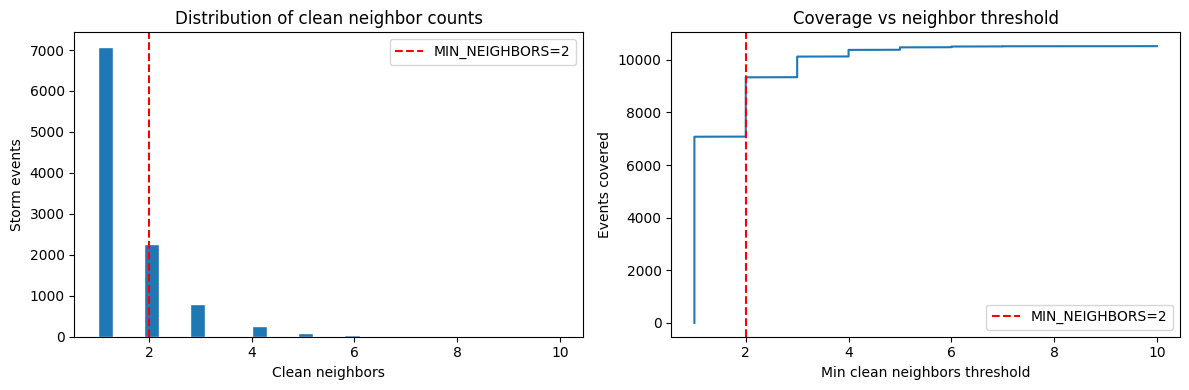

Median clean neighbors: 1
Events with 0 clean neighbors: 0
Events with >= 1 clean neighbor: 10,521
Events with >= 2 clean neighbors: 3,443


In [8]:
import matplotlib.pyplot as plt

event_neighbor_counts = (
    baseline_lookup
    .groupby(['target_fips', 'storm_year', 'storm_month'])['n_clean_neighbors']
    .first()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution histogram
axes[0].hist(event_neighbor_counts, bins=30, edgecolor='white')
axes[0].set_xlabel('Clean neighbors')
axes[0].set_ylabel('Storm events')
axes[0].set_title('Distribution of clean neighbor counts')
axes[0].axvline(x=2, color='red', linestyle='--', label='MIN_NEIGHBORS=2')
axes[0].legend()

# Cumulative coverage curve
sorted_counts = event_neighbor_counts.sort_values()
cumulative = range(1, len(sorted_counts) + 1)
axes[1].plot(sorted_counts.values, cumulative)
axes[1].set_xlabel('Min clean neighbors threshold')
axes[1].set_ylabel('Events covered')
axes[1].set_title('Coverage vs neighbor threshold')
axes[1].axvline(x=2, color='red', linestyle='--', label='MIN_NEIGHBORS=2')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Median clean neighbors: {event_neighbor_counts.median():.0f}')
print(f'Events with 0 clean neighbors: {(event_neighbor_counts == 0).sum():,}')
print(f'Events with >= 1 clean neighbor: {(event_neighbor_counts >= 1).sum():,}')
print(f'Events with >= 2 clean neighbors: {(event_neighbor_counts >= 2).sum():,}')

## Validate

In [9]:
# Validate
assert baseline_lookup['target_fips'].str.len().eq(5).all(), 'FIPS not all 5 digits'
assert baseline_lookup['t'].between(-PRE_EVENT_MONTHS, POST_EVENT_MONTHS).all(), 'Offset t out of window range'
assert baseline_lookup['baseline_zhvi'].isnull().sum() == 0 or True, f'Missing baseline ZHVI: {baseline_lookup["baseline_zhvi"].isnull().sum():,} rows'
assert baseline_lookup.duplicated(['target_fips', 'storm_year', 'storm_month', 't']).sum() == 0, 'Duplicate event-offset rows'

missing = baseline_lookup['baseline_zhvi'].isnull().sum()
if missing > 0:
    print(f'Warning: {missing:,} rows missing baseline_zhvi — neighbor had no ZHVI at that month')

## Export

In [10]:
PRE_EVENT_MONTHS  = 3
POST_EVENT_MONTHS = 9
MIN_NEIGHBORS     = 1



baseline_lookup.to_pickle('../data/processed/baseline_lookup.pkl')
print(f'Saved baseline_lookup.pkl')
print(f'Shape: {baseline_lookup.shape}')
print(f'Storm events covered: {baseline_lookup.groupby(["target_fips","storm_year","storm_month"]).ngroups:,}')

print('All assertions passed')
print(f'\nSample:')
baseline_lookup[baseline_lookup['n_clean_neighbors'] >= MIN_NEIGHBORS].head(13)

Saved baseline_lookup.pkl
Shape: (136773, 8)
Storm events covered: 10,521
All assertions passed

Sample:


,target_fips,storm_year,storm_month,t,year,month,baseline_zhvi,n_clean_neighbors
0,20099,2021,5,-3,2021,2,130324.681301,1
1,20099,2021,5,-2,2021,3,132765.166061,1
2,20099,2021,5,-1,2021,4,134804.348678,1
3,20099,2021,5,0,2021,5,136405.455343,1
4,20099,2021,5,1,2021,6,137955.844759,1
5,20099,2021,5,2,2021,7,138426.529757,1
6,20099,2021,5,3,2021,8,138296.824152,1
7,20099,2021,5,4,2021,9,137697.500108,1
8,20099,2021,5,5,2021,10,137999.770670,1
9,20099,2021,5,6,2021,11,139596.447449,1


In [11]:
zhvi_fips = set(zhvi_idx.index.get_level_values('stcofips'))
neighbor_fips = set(baseline_lookup['target_fips'].unique())  # proxy

# Better — get unique neighbors from adjacency dict
all_neighbors = set(n for neighbors_list in neighbors.values() for n in neighbors_list)
unmatched = all_neighbors - zhvi_fips
print(f'Neighbor FIPS not in zhvi_idx: {len(unmatched):,}')
print(f'Examples: {list(unmatched)[:10]}')

Neighbor FIPS not in zhvi_idx: 0
Examples: []


In [12]:
print(f'Total storm events in affected set: {len(affected):,}')
print(f'Events in baseline_lookup: {baseline_lookup.groupby(["target_fips","storm_year","storm_month"]).ngroups:,}')
print(f'Events with any null baseline: {baseline_lookup[baseline_lookup["baseline_zhvi"].isnull()].groupby(["target_fips","storm_year","storm_month"]).ngroups:,}')
print(f'Events with complete windows: {baseline_lookup.groupby(["target_fips","storm_year","storm_month"]).filter(lambda x: x["baseline_zhvi"].notnull().all()).groupby(["target_fips","storm_year","storm_month"]).ngroups:,}')

Total storm events in affected set: 48,978
Events in baseline_lookup: 10,521
Events with any null baseline: 1,724
Events with complete windows: 8,797


In [13]:
null_events = (
    baseline_lookup[baseline_lookup['baseline_zhvi'].isnull()]
    .groupby(['storm_year', 'storm_month'])
    .size()
    .reset_index(name='null_count')
    .sort_values(['storm_year', 'storm_month'])
)
print(null_events)

    storm_year  storm_month  null_count
0         2020            1          13
1         2020            2          13
2         2020            3          13
3         2020            4          65
4         2020            5          39
5         2020            6          26
6         2020            7          10
7         2020            8          35
8         2020            9           2
9         2021            3          13
10        2021            4          39
11        2021            5         145
12        2021            6          81
13        2021            7          23
14        2021            8          13
15        2021            9          21
16        2021           10          28
17        2022            3           2
18        2022            4          27
19        2022            7          39
20        2022            8          13
21        2022            9          26
22        2023            3          22
23        2023            8          12
